In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.metrics as skm
from tqdm import tqdm
from scipy.stats import ks_2samp
from scipy import stats

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.0' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Functions

In [2]:
# get metrics
def get_metrics(y_true, y_hat):
    dict_eval_metrics = {
        'Explained Variance': skm.explained_variance_score(y_true=y_true, y_pred=y_hat),
        'Mean Error': (y_true - y_hat).mean(),
        'Mean Absolute Error': skm.mean_absolute_error(y_true=y_true, y_pred=y_hat),
        'Mean Squared Error': skm.mean_squared_error(y_true=y_true, y_pred=y_hat),
        'Rooot Mean Squared Error': np.sqrt(skm.mean_squared_error(y_true=y_true, y_pred=y_hat)),
    }
    # make df
    df_tmp = pd.DataFrame({
        'Metric': list(dict_eval_metrics.keys()),
        'Score': list(dict_eval_metrics.values()),
    })
    # return
    return df_tmp

In [3]:
def distribution_plots(list_x, list_y, str_title='Distributions of Gen XI No BK vs. BK 7', str_label_x='NoBK', str_label_y='BK7'):
    # ks test
    flt_ks, flt_p = ks_2samp(list_x, list_y)
    # logic
    if flt_p <= 0.05:
        str_sig = 'Distributions are Significantly Different'
    else:
        str_sig = 'Distributions are Not Significantly Different'

    fig, ax = plt.subplots(figsize=(9,5))
    str_title = f"""
    {str_title}
    {str_sig} (KS = {flt_ks:0.3f}; p = {flt_p:0.3f})
    """
    ax.set_title(str_title)
    sns.kdeplot(list_x, label=str_label_x)
    sns.kdeplot(list_y, label=str_label_y)
    plt.legend()
    plt.show()

In [4]:
def train_test_split(df, flt_prop_train=0.66):
    int_nrows = df.shape[0]
    df['row'] = list(range(1, int_nrows+1))
    df['row'] = df['row'] / int_nrows
    df['data_set'] = df['row'].apply(
        lambda x: 'train' if x <= flt_prop_train else 'test',
    )
    df.drop('row', axis=1, inplace=True)
    return df

In [5]:
def get_tier(fltDebtorScore):
    if fltDebtorScore <= 0.04:
        return 'A1'
    elif fltDebtorScore <= 0.07:
        return 'A'
    elif fltDebtorScore <= 0.14:
        return 'B'
    elif fltDebtorScore <= 0.17:
        return 'C'
    elif fltDebtorScore <= 0.2015:
        return 'D'
    else:
        return 'Decline'

### Constants

In [6]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
# task
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')
# subtask
str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')
str_dirname_output = './output'
str_variant = 'noPTImodel7'

Project: 20231010-gen-xii
Task: 08_retro_scoring
Subtask: 10_match_distributions


### Output dir

In [7]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant dir

In [8]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Import Gen XI scores

In [9]:
str_filename = 'df_genxi_scores.csv'
str_uri = f's3://{str_project}/{str_task}/09_swap_in_swap_out_plot/{str_filename}'
df = pd.read_csv(str_uri)
# rename
dict_rename = {
    'App_date': 'applicationdate',
    'fltDebtorScore': 'ECNL_genxi',
}
df.rename(columns=dict_rename, inplace=True)
df['applicationdate'] = pd.to_datetime(df['applicationdate'])
# show
df

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:272: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


,applicationdate,bigAccountId,ECNL_genxi,strScoreCardVersion
0,2022-01-03 14:47:37.927,5838462,0.141234,genxi
1,2022-01-03 15:01:23.737,5872184,0.148215,genxi
2,2022-01-03 15:17:17.263,5828280,0.277955,genxi
3,2022-01-03 15:26:18.493,5869179,0.218271,genxi
4,2022-01-03 15:33:01.133,5856159,0.093084,genxi
...,...,...,...,...
54698,2024-02-16 22:56:54.567,7537277,0.127174,genxi_v2_2
54699,2024-02-16 22:59:13.010,7559506,0.149535,genxi_v2_2
54700,2024-02-16 23:00:35.170,7562092,0.182683,genxi_v2_2
54701,2024-02-16 23:00:38.560,7565692,0.089162,genxi_v2_2


### Import Gen XII scores

In [10]:
str_filename = 'df.csv'
str_uri = f's3://{str_project}/{str_task}/08_segment_distributions/02_gen_xii_production/{str_filename}'
df_tmp = pd.read_csv(str_uri)
# rename
dict_rename = {
    'ECNL_production': 'ECNL_genxii',
}
df_tmp.rename(columns=dict_rename, inplace=True)
df_tmp['intopenbktype__app'] = df_tmp['intopenbktype__app'].astype(str)
# show
df_tmp

,bigAccountId,intopenbktype__app,yhat_pricing_pd,yhat_pricing_lgd,ECNL_genxii
0,5776704,13.0,0.558671,0.382644,0.213772
1,5798398,13.0,0.369617,0.419103,0.154908
2,5800475,nan,0.570611,0.455198,0.259741
3,5808212,nan,0.615788,0.500495,0.308199
4,5809809,nan,0.416278,0.452133,0.188213
...,...,...,...,...,...
49217,7373944,nan,0.352573,0.412792,0.145540
49218,7373949,nan,0.395338,0.440485,0.174140
49219,7373986,13.0,0.075065,0.233043,0.017493
49220,7374018,13.0,0.125765,0.313343,0.039408


### Join

In [11]:
df = pd.merge(
    left=df,
    right=df_tmp,
    on='bigAccountId',
    how='inner',
)
# subset
list_cols = [
    'applicationdate',
    'bigAccountId',
    'intopenbktype__app',
    'ECNL_genxi',
    'ECNL_genxii',
]
df = df[list_cols].copy()
df

,applicationdate,bigAccountId,intopenbktype__app,ECNL_genxi,ECNL_genxii
0,2022-01-03 14:47:37.927,5838462,13.0,0.141234,0.114173
1,2022-01-03 15:01:23.737,5872184,nan,0.148215,0.120413
2,2022-01-03 15:17:17.263,5828280,nan,0.277955,0.151528
3,2022-01-03 15:26:18.493,5869179,nan,0.218271,0.148900
4,2022-01-03 15:33:01.133,5856159,nan,0.093084,0.063002
...,...,...,...,...,...
49217,2024-02-07 22:38:12.747,7228265,nan,0.120231,0.280344
49218,2024-02-07 22:43:18.877,7356503,13.0,0.082838,0.169585
49219,2024-02-08 23:36:26.267,7321766,13.0,0.049379,0.107227
49220,2024-02-09 20:37:08.987,7306479,13.0,-0.005514,0.009188


### Get tier (Gen XI)

In [12]:
df['tier_genxi'] = df['ECNL_genxi'].apply(get_tier)

### Remove declines

In [13]:
df = df[df['tier_genxi'] != 'Decline'].copy()
df

,applicationdate,bigAccountId,intopenbktype__app,ECNL_genxi,ECNL_genxii,tier_genxi
0,2022-01-03 14:47:37.927,5838462,13.0,0.141234,0.114173,C
1,2022-01-03 15:01:23.737,5872184,nan,0.148215,0.120413,C
4,2022-01-03 15:33:01.133,5856159,nan,0.093084,0.063002,B
5,2022-01-03 15:39:07.357,5875280,nan,0.140743,0.147733,C
9,2022-01-03 16:44:16.800,5874199,nan,0.134925,0.062434,B
...,...,...,...,...,...,...
49217,2024-02-07 22:38:12.747,7228265,nan,0.120231,0.280344,B
49218,2024-02-07 22:43:18.877,7356503,13.0,0.082838,0.169585,B
49219,2024-02-08 23:36:26.267,7321766,13.0,0.049379,0.107227,A
49220,2024-02-09 20:37:08.987,7306479,13.0,-0.005514,0.009188,A1


### Min and max dates

In [14]:
dtm_min = df['applicationdate'].min()
dtm_max = df['applicationdate'].max()
print(f'Min date: {dtm_min.date()}; Max date: {dtm_max.date()}')

Min date: 2022-01-03; Max date: 2024-02-09


### Distributions of Predictions Overall

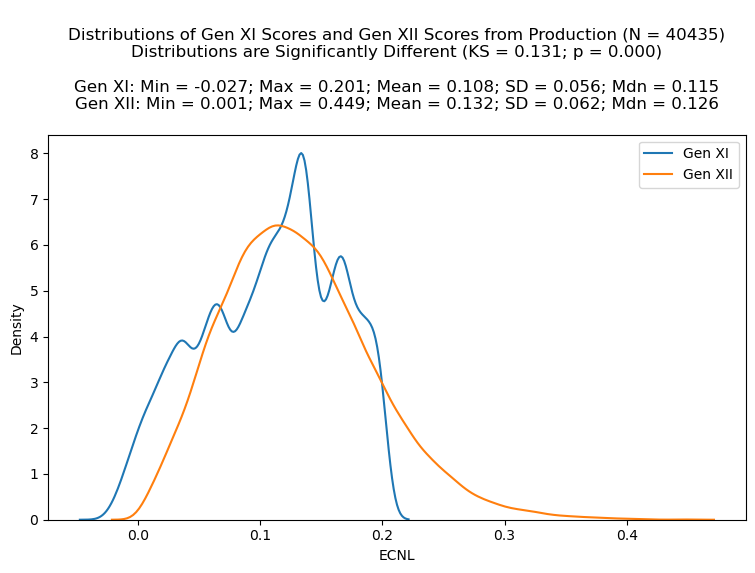

In [15]:
# gen xi
list_x = list(df['ECNL_genxi'])
flt_min_x = np.min(list_x)
flt_max_x = np.max(list_x)
flt_mean_x = np.mean(list_x)
flt_std_x = np.std(list_x)
flt_mdn_x = np.median(list_x)
# gen xii
list_y = list(df['ECNL_genxii'])
flt_min_y = np.min(list_y)
flt_max_y = np.max(list_y)
flt_mean_y = np.mean(list_y)
flt_std_y = np.std(list_y)
flt_mdn_y = np.median(list_y)
# ks test
flt_ks, flt_p = ks_2samp(list_x, list_y)
# logic
if flt_p <= 0.05:
    str_sig = 'Distributions are Significantly Different'
else:
    str_sig = 'Distributions are Not Significantly Different'

# plot
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distributions of Gen XI Scores and Gen XII Scores from Production (N = {df.shape[0]})
{str_sig} (KS = {flt_ks:0.3f}; p = {flt_p:0.3f})

Gen XI: Min = {flt_min_x:0.3f}; Max = {flt_max_x:0.3f}; Mean = {flt_mean_x:0.3f}; SD = {flt_std_x:0.3f}; Mdn = {flt_mdn_x:0.3f}
Gen XII: Min = {flt_min_y:0.3f}; Max = {flt_max_y:0.3f}; Mean = {flt_mean_y:0.3f}; SD = {flt_std_y:0.3f}; Mdn = {flt_mdn_y:0.3f}
"""
ax.set_title(str_title)
ax.set_xlabel('ECNL')
# plot lines
sns.kdeplot(list_x, label='Gen XI')
sns.kdeplot(list_y, label='Gen XII')
# legend
plt.legend()

# save
str_filename = 'plt_kde_prod.png'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

### Look at distributions of non-bk vs BK7 for Gen XI

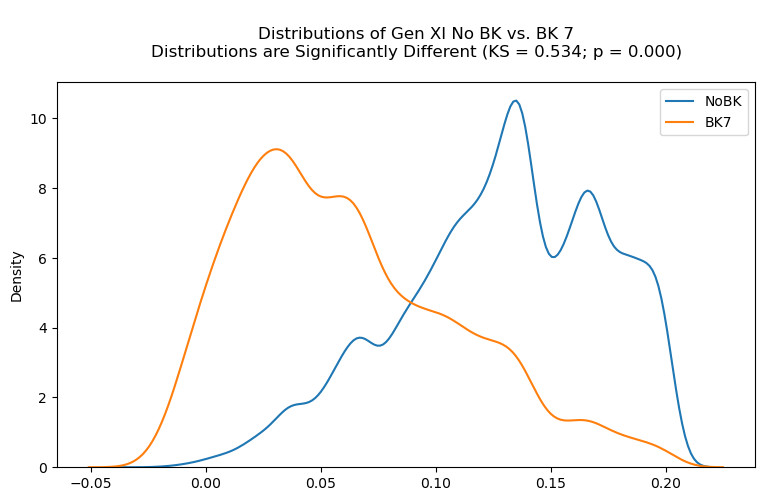

In [16]:
# non-bk
list_x = list(df[df['intopenbktype__app'].isin(['nan'])]['ECNL_genxi'])
# bk7
list_y = list(df[df['intopenbktype__app'].isin(['7.0'])]['ECNL_genxi'])
distribution_plots(
    list_x=list_x, 
    list_y=list_y,
)

### See if I can get the Ch 7 to match the No BK using linear interpolation

In [17]:
# non-bk
list_x = list(df[df['intopenbktype__app'].isin(['nan'])]['ECNL_genxi'])
# bk7
list_y = list(df[df['intopenbktype__app'].isin(['7.0'])]['ECNL_genxi'])

In [18]:
# quantiles for both distributions
arr_target_quantiles = np.percentile(list_x, np.linspace(0, 100, 100))
arr_iv_quantiles = np.percentile(list_y, np.linspace(0, 100, 100))
# map quantiles and transform data
list_mapped_data = list(np.interp(list_y, arr_iv_quantiles, arr_target_quantiles))

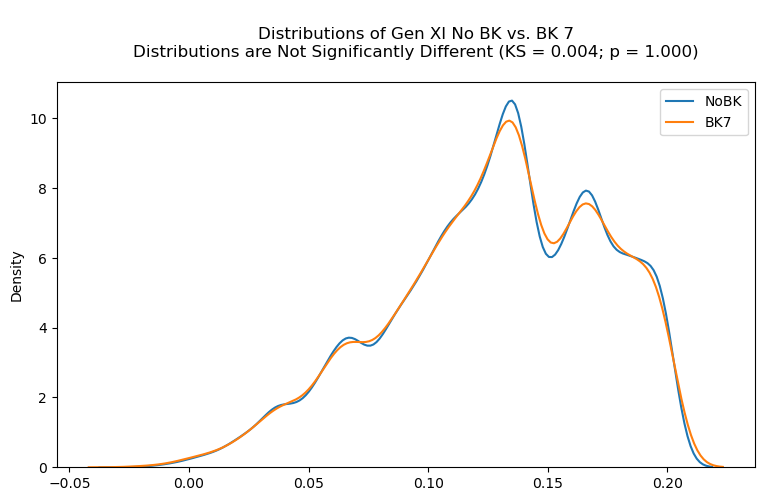

In [19]:
distribution_plots(
    list_x=list_x, 
    list_y=list_mapped_data,
)

### Linear interpolation with train, valid, test split

In [20]:
df = train_test_split(
    df=df, 
    flt_prop_train=0.66,
)
# train test split
df_train = df[df['data_set'] == 'train'].copy()
df_test = df[df['data_set'] == 'test'].copy()
df_test

,applicationdate,bigAccountId,intopenbktype__app,ECNL_genxi,ECNL_genxii,tier_genxi,data_set
35448,2023-05-31 16:11:53.977,6847703,nan,0.165837,0.176464,C,test
35449,2023-05-31 16:13:59.077,6774121,nan,0.156765,0.117197,C,test
35450,2023-05-31 16:19:56.150,6834596,nan,0.139773,0.107469,B,test
35451,2023-05-31 16:22:12.980,6846517,nan,0.151019,0.118836,C,test
35452,2023-05-31 16:35:55.730,6820414,13.0,0.026532,0.077910,A1,test
...,...,...,...,...,...,...,...
49217,2024-02-07 22:38:12.747,7228265,nan,0.120231,0.280344,B,test
49218,2024-02-07 22:43:18.877,7356503,13.0,0.082838,0.169585,B,test
49219,2024-02-08 23:36:26.267,7321766,13.0,0.049379,0.107227,A,test
49220,2024-02-09 20:37:08.987,7306479,13.0,-0.005514,0.009188,A1,test


Preview of untransformed data: [-0.008822, 0.016267, 0.163951, 0.201389]


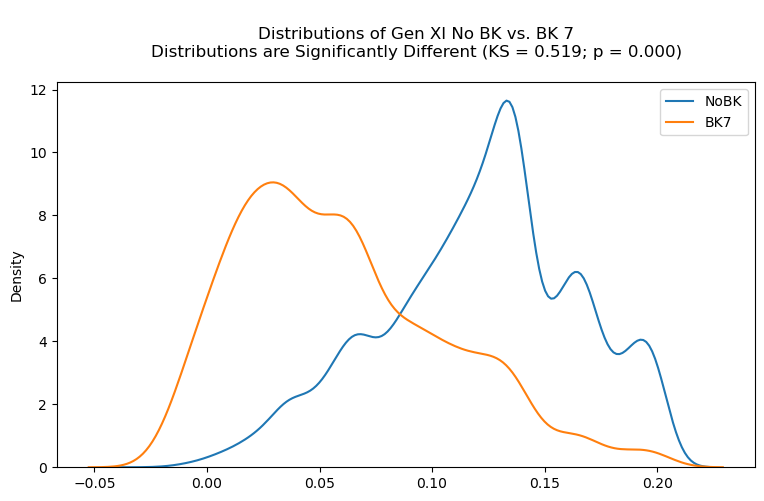

In [21]:
# non-bk
list_x = list(df_test[df_test['intopenbktype__app'].isin(['nan'])]['ECNL_genxi'])
# bk7
list_y = list(df_test[df_test['intopenbktype__app'].isin(['7.0'])]['ECNL_genxi'])
print(f'Preview of untransformed data: {list_y[:4]}')
distribution_plots(
    list_x=list_x, 
    list_y=list_y,
)

In [22]:
# non-bk
list_x = list(df_train[df_train['intopenbktype__app'].isin(['nan'])]['ECNL_genxi'])
# bk7
list_y = list(df_train[df_train['intopenbktype__app'].isin(['7.0'])]['ECNL_genxi'])

In [23]:
# quantiles for both distributions
arr_target_quantiles = np.percentile(list_x, np.linspace(0, 100, 100))
arr_iv_quantiles = np.percentile(list_y, np.linspace(0, 100, 100))
# map quantiles and transform data
list_z = list(df_test[df_test['intopenbktype__app'].isin(['7.0'])]['ECNL_genxi'])
list_mapped_data = list(np.interp(list_z, arr_iv_quantiles, arr_target_quantiles))
print(f'Preview of transformed data: {list_mapped_data[:4]}')

Preview of transformed data: [0.03360203022755017, 0.08677884393466363, 0.19618637363314564, 0.20149528226171987]


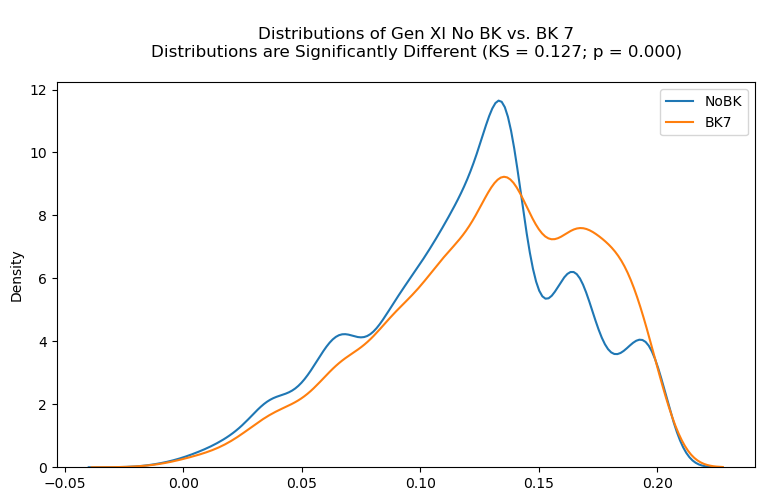

In [24]:
distribution_plots(
    list_x=list(df_test[df_test['intopenbktype__app'].isin(['nan'])]['ECNL_genxi']), 
    list_y=list_mapped_data,
)

### Try a list of 2 (i.e., POC production)

In [25]:
# map quantiles and transform data
list_z = list(df_test[df_test['intopenbktype__app'].isin(['7.0'])]['ECNL_genxi'])[:2] # get a
print(f'Untransformed data: {list_z[:2]}')
list_mapped_data = list(np.interp(list_z, arr_iv_quantiles, arr_target_quantiles))
print(f'Transformed data: {list_mapped_data}')

Untransformed data: [-0.008822, 0.016267]
Transformed data: [0.03360203022755017, 0.08677884393466363]


### Map A1 to D tiers

Preview of untransformed data: [0.026532, -0.008822, 0.016267, 0.004592]


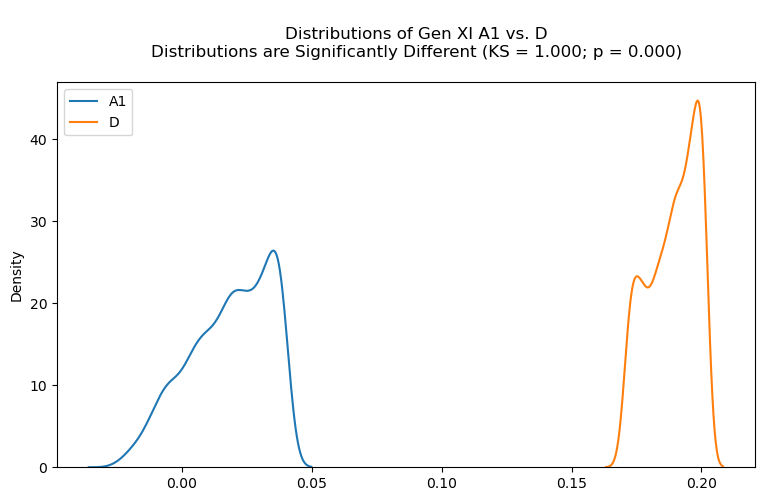

In [26]:
str_tier_x = 'A1'
str_tier_y = 'D'
# x
list_x = list(df_test[df_test['tier_genxi'] == str_tier_x].copy()['ECNL_genxi'])
# y
list_y = list(df_test[df_test['tier_genxi'] == str_tier_y].copy()['ECNL_genxi'])
print(f'Preview of untransformed data: {list_x[:4]}')
distribution_plots(
    list_x=list_x, 
    list_y=list_y,
    str_title=f'Distributions of Gen XI {str_tier_x} vs. {str_tier_y}',
    str_label_x=str_tier_x,
    str_label_y=str_tier_y,
)

In [27]:
# get training distributions
list_x = list(df_train[df_train['tier_genxi'] == str_tier_x].copy()['ECNL_genxi'])
list_y = list(df_train[df_train['tier_genxi'] == str_tier_y].copy()['ECNL_genxi'])
# quantiles for both distributions
arr_quantiles_x = np.percentile(list_x, np.linspace(0, 100, 100))
arr_quantiles_y = np.percentile(list_y, np.linspace(0, 100, 100))
# get test distribution that we want to transform
list_z = list(df_test[df_test['tier_genxi'] == str_tier_x].copy()['ECNL_genxi'])
# map
list_mapped_data = list(np.interp(
    list_z, 
    arr_quantiles_x, 
    arr_quantiles_y,
))
print(f'Preview of transformed data: {list_mapped_data[:4]}')

Preview of transformed data: [0.18999350857703703, 0.1723662874161228, 0.18310240396139243, 0.1775710940860215]


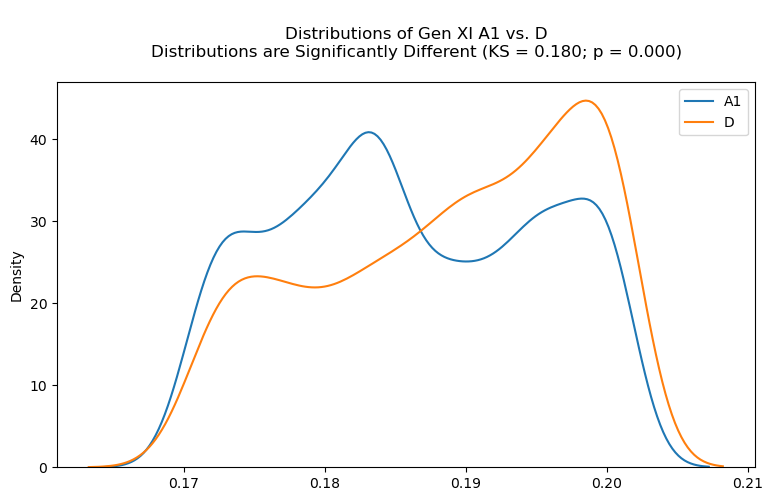

In [28]:
# y
list_y = list(df_test[df_test['tier_genxi'] == str_tier_y].copy()['ECNL_genxi'])
distribution_plots(
    list_x=list_mapped_data, 
    list_y=list_y,
    str_title=f'Distributions of Gen XI {str_tier_x} vs. {str_tier_y}',
    str_label_x=str_tier_x,
    str_label_y=str_tier_y,
)

### Hypothetical distributions

In [29]:
list_str_tier = [
    'A1',
    'A',
    'B',
    'C',
    'D',
]

#### Current distributions of ECNL by tier

In [30]:
# get the "historical" arrays
dict_history = {}
for str_tier in tqdm(list_str_tier):
    # subset
    df_tmp = df_train[df_train['tier_genxi'] == str_tier].copy()
    # get the ecnl array
    list_tmp = list(df_tmp['ECNL_genxi'])
    # assign
    dict_history[str_tier] = list_tmp

100%|██████████| 5/5 [00:00<00:00, 317.50it/s]


100%|██████████| 5/5 [00:00<00:00, 14.30it/s]


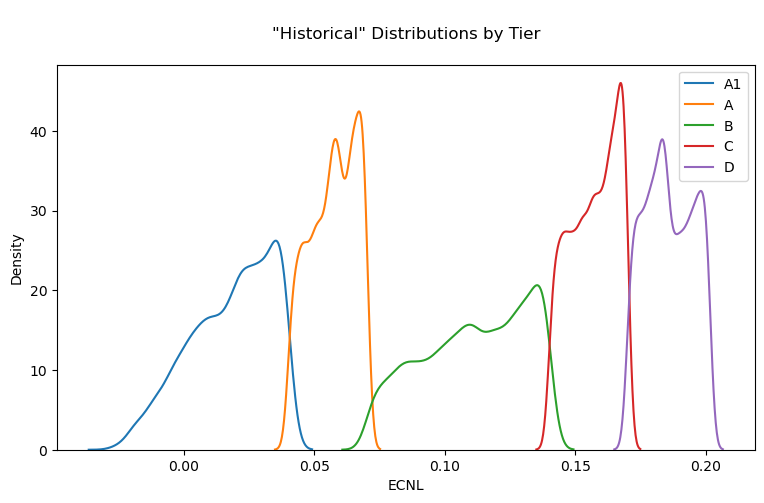

In [31]:
# ax
fig, ax = plt.subplots(figsize=(9,5))
# title
str_title = f"""
"Historical" Distributions by Tier
"""
ax.set_title(str_title)
# x label
ax.set_xlabel('ECNL')
# plot
for str_tier in tqdm(list_str_tier):
    sns.kdeplot(dict_history[str_tier], label=str_tier)

# legend
plt.legend()
# show
plt.show() 

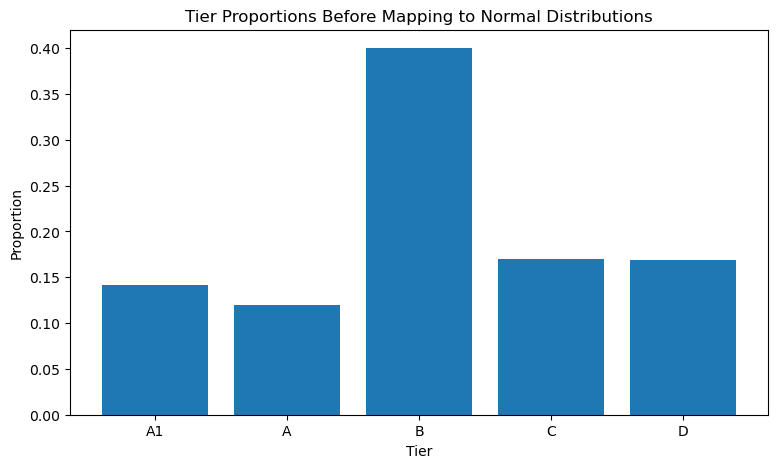

In [32]:
# freq
ser_freq = df_train['tier_genxi'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['tier','proportion']
list_order = [
    'A1',
    'A',
    'B',
    'C',
    'D',
    'Decline',
]
df_freq['tier'] = df_freq['tier'].astype(pd.CategoricalDtype(categories=list_order, ordered=True))
df_freq.sort_values(by='tier', inplace=True)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Tier Proportions Before Mapping to Normal Distributions')
ax.set_xlabel('Tier')
ax.set_ylabel('Proportion')
ax.bar(df_freq['tier'], df_freq['proportion'])
plt.show()

#### Hypothetical distributions

In [33]:
# # set random seed
# np.random.seed(42)
# # size of each array
# int_size = 1000
# # increment
# flt_increment = 0.000001
# # mean
# flt_mean = np.mean([0, 0.04])

# # get a standard deviation so there are no negatives in a1
# flt_sd = 0.02
# list_dict_row = []
# while True:
#     list_tmp = list(np.random.normal(loc=flt_mean, size=int_size, scale=flt_sd))
#     flt_min = np.min(list_tmp)
#     dict_row = {
#         'flt_sd': flt_sd,
#         'flt_min': flt_min,
#     }
#     list_dict_row.append(dict_row)
#     # logic
#     if flt_min > 0.004:
#         break
#     else:
#         flt_sd -= flt_increment
# # make df
# df_tmp = pd.DataFrame(list_dict_row)
# # best sd
# flt_sd = df_tmp['flt_sd'].iloc[-1]

# # plot
# fig, ax = plt.subplots(figsize=(9,5))
# str_title = f"""
# Minimum Value by Standard Deviation (N = {df_tmp.shape[0]})
# Best Standard Deviation to Minimize Negative ECNL = {flt_sd:0.4f}
# """
# ax.set_title(str_title)
# ax.set_xlabel('Standard Deviation')
# ax.set_ylabel('Minimum Value')
# ax.plot(df_tmp['flt_sd'], df_tmp['flt_min'])
# plt.show()

In [34]:
# # create hypothetical arrays
# dict_norm = {}

# # a1
# flt_mean = np.mean([0, 0.04])
# dict_norm['A1'] = list(np.random.normal(loc=flt_mean, size=int_size, scale=flt_sd))

# # a
# flt_mean = np.mean([0.04, 0.07])
# dict_norm['A'] = list(np.random.normal(loc=flt_mean, size=int_size, scale=flt_sd))

# # b
# flt_mean = np.mean([0.07, 0.14])
# dict_norm['B'] = list(np.random.normal(loc=flt_mean, size=int_size, scale=flt_sd))

# # c
# flt_mean = np.mean([0.14, 0.17])
# dict_norm['C'] = list(np.random.normal(loc=flt_mean, size=int_size, scale=flt_sd))

# # d
# flt_mean = np.mean([0.17, 0.2015])
# dict_norm['D'] = list(np.random.normal(loc=flt_mean, size=int_size, scale=flt_sd))

In [36]:
int_size = 1000

# create hypothetical arrays
dict_norm = {}

# a1
dict_norm['A1'] = list(np.random.uniform(0, 0.04, int_size))

# a
dict_norm['A'] = list(np.random.uniform(0.04, 0.07, int_size))

# b
dict_norm['B'] = list(np.random.uniform(0.07, 0.14, int_size))

# c
dict_norm['C'] = list(np.random.uniform(0.14, 0.17, int_size))

# d
dict_norm['D'] = list(np.random.uniform(0.17, 0.2015, int_size))

100%|██████████| 5/5 [00:00<00:00, 38.11it/s]


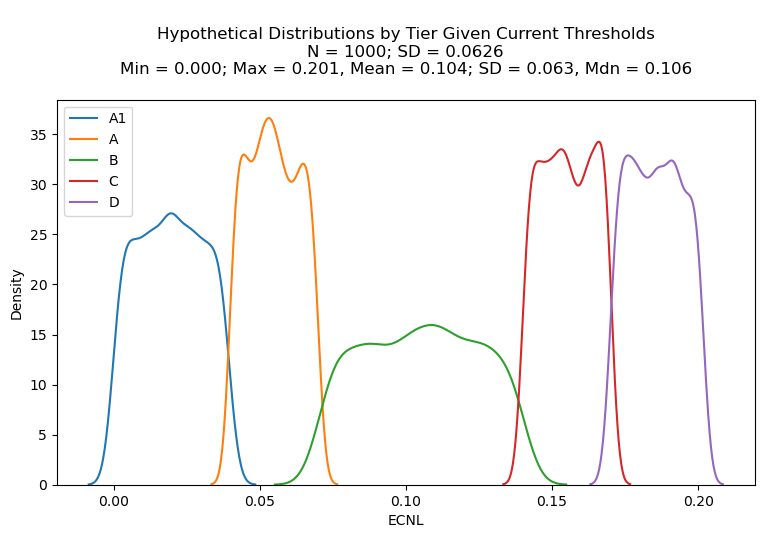

In [41]:
# get the metrics for the plot
list_values = []
for str_tier in tqdm(list_str_tier):
    list_values.extend(dict_norm[str_tier])
flt_min = np.min(list_values)
flt_max = np.max(list_values)
flt_mean = np.mean(list_values)
flt_sd = np.std(list_values)
flt_mdn = np.median(list_values)

# ax
fig, ax = plt.subplots(figsize=(9,5))
# title
str_title = f"""
Hypothetical Distributions by Tier Given Current Thresholds
N = {int_size}; SD = {flt_sd:0.4f}
Min = {flt_min:0.3f}; Max = {flt_max:0.3f}, Mean = {flt_mean:0.3f}; SD = {flt_sd:0.3f}, Mdn = {flt_mdn:0.3f}
"""
ax.set_title(str_title)
# x label
ax.set_xlabel('ECNL')
# plot
for str_tier in tqdm(list_str_tier):
    sns.kdeplot(dict_norm[str_tier], label=str_tier, ax=ax)

# legend
plt.legend()
# show
plt.show()   

#### Map the production scores to hypothetical distributions

In [38]:
# get the "production" arrays
dict_production = {}
for str_tier in tqdm(list_str_tier):
    # subset
    df_tmp = df_test[df_test['tier_genxi'] == str_tier].copy()
    # get the ecnl array
    list_tmp = list(df_tmp['ECNL_genxi'])
    # assign
    dict_production[str_tier] = list_tmp

100%|██████████| 5/5 [00:00<00:00, 488.88it/s]


In [39]:
# get production distributions to match the hypothetical normal distributions
dict_mapped = {}
for str_tier in tqdm(list_str_tier):
    # get quantiles for hypothetical target
    arr_quantiles_target = np.percentile(dict_norm[str_tier], np.linspace(0, 100, 100))
    # get quantiles for historical distributions
    arr_quantiles_history = np.percentile(dict_history[str_tier], np.linspace(0, 100, 100))
    # interpolate the production
    list_mapped = list(np.interp(
        dict_production[str_tier], 
        arr_quantiles_history, 
        arr_quantiles_target,
    ))
    # assign
    dict_mapped[str_tier] = list_mapped

100%|██████████| 5/5 [00:00<00:00, 516.96it/s]


100%|██████████| 5/5 [00:00<00:00, 22.54it/s]


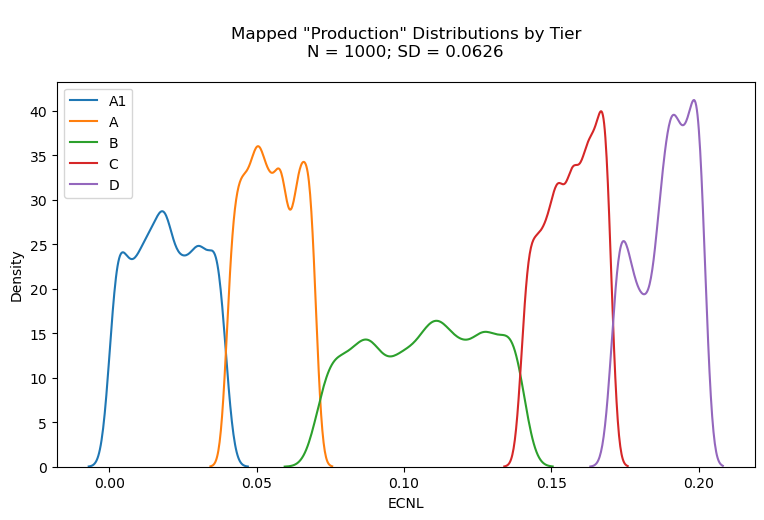

In [40]:
# ax
fig, ax = plt.subplots(figsize=(9,5))
# title
str_title = f"""
Mapped "Production" Distributions by Tier
N = {int_size}; SD = {flt_sd:0.4f}
"""
ax.set_title(str_title)
# x label
ax.set_xlabel('ECNL')
# plot
for str_tier in tqdm(list_str_tier):
    sns.kdeplot(dict_mapped[str_tier], label=str_tier, ax=ax)

# legend
plt.legend()
# show
plt.show() 

#### Re-tier the mapped values

In [42]:
list_values = []
for str_tier in tqdm(list_str_tier):
    list_tmp = dict_mapped[str_tier]
    list_values.extend(list_tmp)

100%|██████████| 5/5 [00:00<00:00, 27594.11it/s]


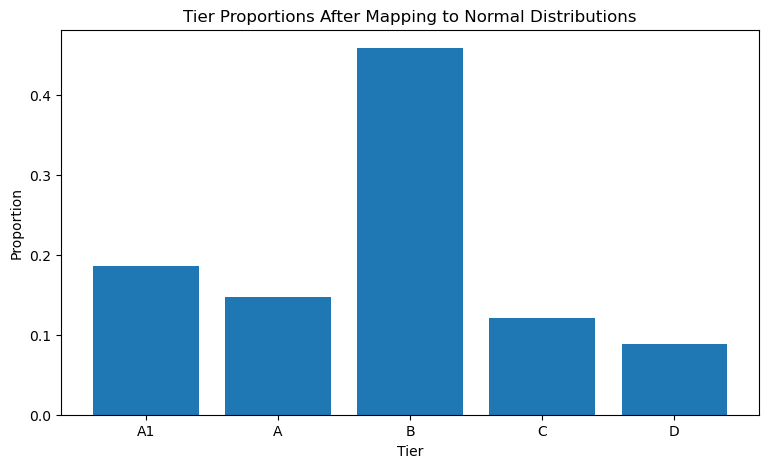

In [43]:
# make df
df_tmp = pd.DataFrame({
    'ECNL_genxi_mapped': list_values,
})
# clip
df_tmp['ECNL_genxi_mapped'] = df_tmp['ECNL_genxi_mapped'].clip(lower=0)
# tier
df_tmp['tier_mapped'] = df_tmp['ECNL_genxi_mapped'].apply(get_tier)
# freq
ser_freq = df_tmp['tier_mapped'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['tier_mapped','proportion']
list_order = [
    'A1',
    'A',
    'B',
    'C',
    'D',
    'Decline',
]
df_freq['tier_mapped'] = df_freq['tier_mapped'].astype(pd.CategoricalDtype(categories=list_order, ordered=True))
df_freq.sort_values(by='tier_mapped', inplace=True)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Tier Proportions After Mapping to Distributions')
ax.set_xlabel('Tier')
ax.set_ylabel('Proportion')
ax.bar(df_freq['tier_mapped'], df_freq['proportion'])
plt.show()

100%|██████████| 6/6 [00:00<00:00, 22.28it/s]


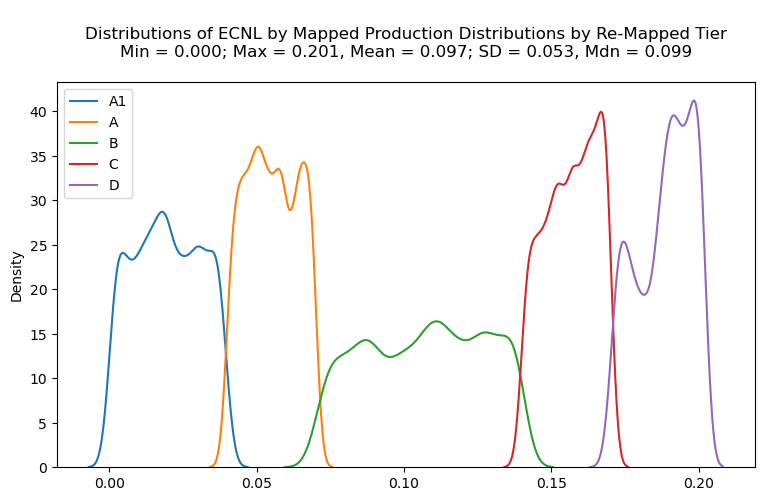

In [44]:
# metrics
flt_min = df_tmp['ECNL_genxi_mapped'].min()
flt_max = df_tmp['ECNL_genxi_mapped'].max()
flt_mean = df_tmp['ECNL_genxi_mapped'].mean()
flt_sd = df_tmp['ECNL_genxi_mapped'].std()
flt_mdn = df_tmp['ECNL_genxi_mapped'].median()

# plot
list_str_tier_new = [
    'A1',
    'A',
    'B',
    'C',
    'D',
    'Decline',
]
# ax
fig, ax = plt.subplots(figsize=(9,5))
# title
str_title = f"""
Distributions of ECNL by Mapped Production Distributions by Re-Mapped Tier
Min = {flt_min:0.3f}; Max = {flt_max:0.3f}, Mean = {flt_mean:0.3f}; SD = {flt_sd:0.3f}, Mdn = {flt_mdn:0.3f}
"""
ax.set_title(str_title)
for str_tier in tqdm(list_str_tier_new):
    list_tmp = list(df_tmp[df_tmp['tier_mapped'] == str_tier].copy()['ECNL_genxi_mapped'])
    sns.kdeplot(list_tmp, label=str_tier, ax=ax)
plt.legend()
plt.show()